In [18]:
#titanic data analysis 
import pandas as pd
df=pd.read_csv("C:\\Users\\kolla\\Downloads\\Titanic-Dataset.csv")

In [19]:
#1st step= data exploration , dimnsion ,dtype , shape size , memory
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#data exploration

In [20]:
df.shape

(891, 12)

In [21]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [22]:
df.info()
# many null values in cabin and age column

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [23]:
#statistical summaries of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
#data cleaning
##1, null value
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:
# if more than 50% null values we must remove the col itself
df=df.drop("Cabin",axis=1)

In [26]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [27]:
# through skewness we decide mean or median
df["Age"].skew()

np.float64(0.38910778230082704)

In [28]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [29]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [30]:
#embarked=categorical colum = always use mode parameter
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [31]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [32]:
# duplicate values
print(df.duplicated().sum())

0


In [33]:
#outliers analysis
import numpy as np
a=df.select_dtypes(include=np.number)


In [34]:
#iqr
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)
    IQR=q3-q1
    UW=q3+1.5*IQR
    LW=q1-1.5*IQR
    outliers=((a[i]>UW)|(a[i]<LW))
    print(f"{i}:-",outliers.sum())
    # remove outliers using loc func
    a.loc[outliers,i]=q2
    print(((a[i]>UW)|(a[i]<LW)).sum())
    





PassengerId:- 0
0
Survived:- 0
0
Pclass:- 0
0
Age:- 66
0
SibSp:- 46
0
Parch:- 213
0
Fare:- 116
0


In [35]:
#data analysis
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [36]:
a=df["Survived"].value_counts()

#most people died in the incident

In [37]:
# Bining Process
bins=[0,18,40,70]
labels=["child","adult","old"]
df["Agegroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Agegroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult


In [39]:
b=df.groupby("Agegroup")["Survived"].mean()*100

In [40]:
# most of the children survived

In [41]:
c=df.groupby("Sex")["Survived"].mean()*100

# most female survived

In [42]:
d=df.groupby("Pclass")["Survived"].mean()*100

In [43]:
e=df.groupby("Pclass")["PassengerId"].count()

In [44]:
df.sort_values(by="Fare",ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Agegroup
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.000000,0,1,PC 17755,512.3292,C,adult
258,259,1,1,"Ward, Miss. Anna",female,35.000000,0,0,PC 17755,512.3292,C,adult
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.000000,0,0,PC 17755,512.3292,C,adult
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.000000,3,2,19950,263.0000,S,adult
438,439,0,1,"Fortune, Mr. Mark",male,64.000000,1,4,19950,263.0000,S,old
...,...,...,...,...,...,...,...,...,...,...,...,...
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.000000,0,0,112050,0.0000,S,adult
815,816,0,1,"Fry, Mr. Richard",male,29.699118,0,0,112058,0.0000,S,adult
466,467,0,2,"Campbell, Mr. William",male,29.699118,0,0,239853,0.0000,S,adult
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,29.699118,0,0,239854,0.0000,S,adult


In [45]:
# Did class privilege save men? Did 3rd-class disadvantage women?
df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64

In [46]:
# Did children in 3rd class survive at the same rate as children in 1st class?
df.groupby(['Pclass', 'Agegroup'])['Survived'].mean() * 100

Pclass  Agegroup
1       child       87.500000
        adult       66.935484
        old         52.054795
2       child       79.310345
        adult       42.148760
        old         38.235294
3       child       35.106383
        adult       23.249300
        old          7.894737
Name: Survived, dtype: float64

#dashboard

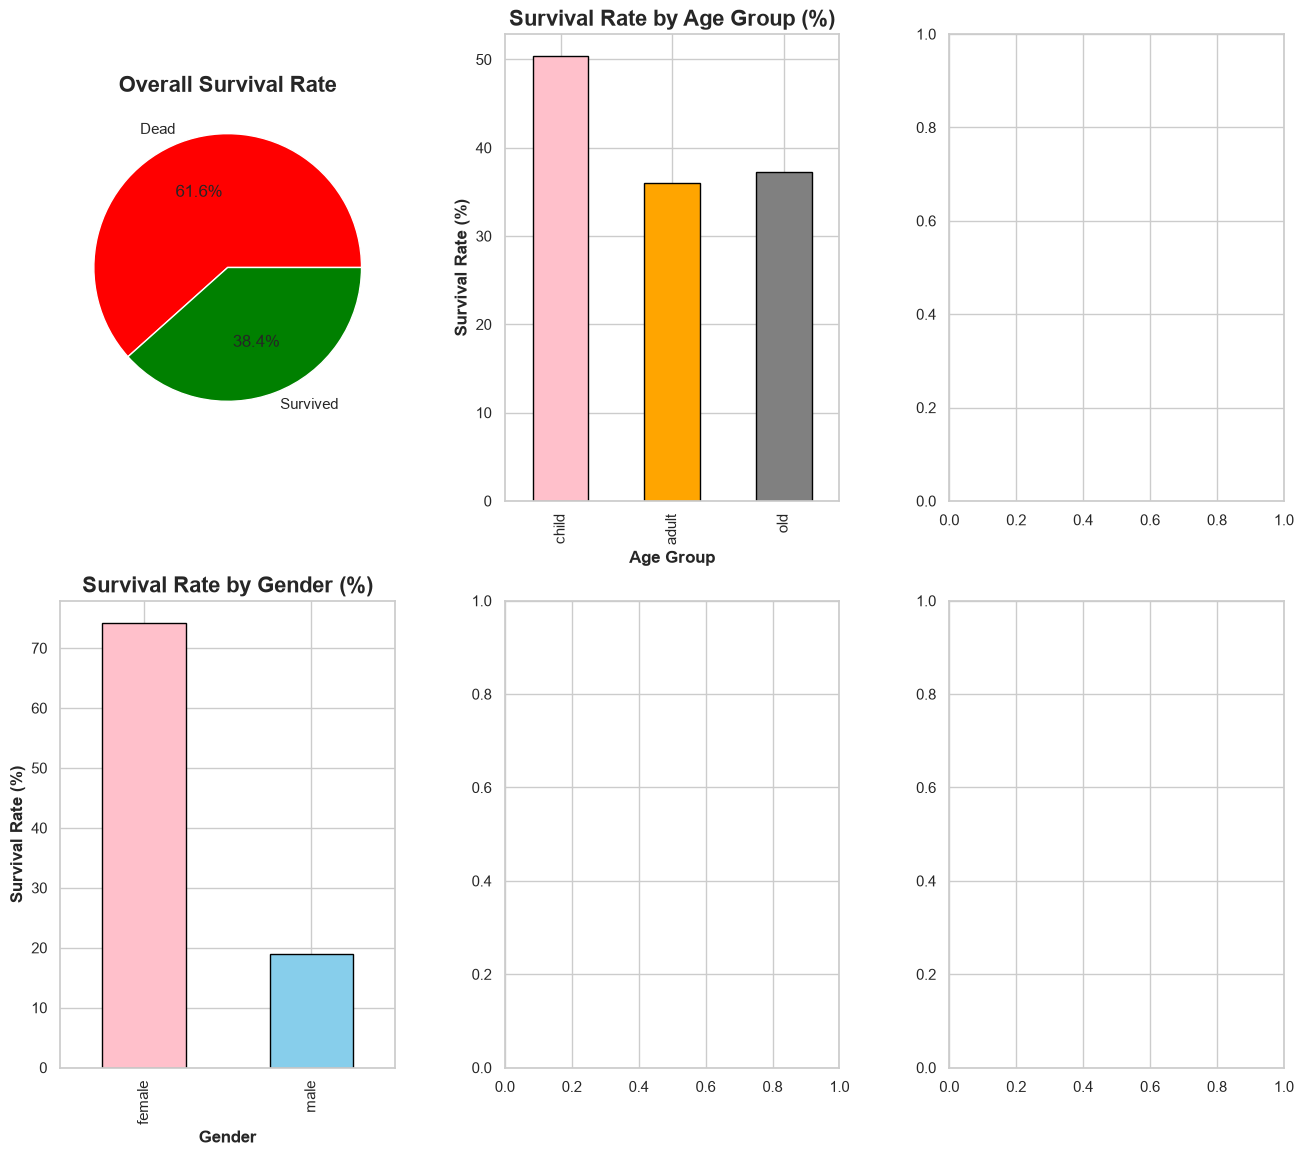

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
#to set a clean visual theme 
sns.set_theme(style="whitegrid")
fig, axes=plt.subplots(nrows=2,ncols=3,figsize=(14,12))
plt.tight_layout(pad=4.0)#space bw charts to prevent overlap
#1
counts=df['Survived'].value_counts()
axes[0,0].pie(
    counts,
    labels=['Dead','Survived'],
    colors=['red','green'],
    autopct='%1.1f%%',)
axes[0, 0].set_title('Overall Survival Rate', fontsize=16, fontweight='bold')

#2.
# 2. Plot as a bar chart in the top-right box
age_survival = df.groupby('Agegroup')['Survived'].mean() * 100
age_survival.plot(
    kind='bar',
    ax=axes[0, 1],
    color=['pink', 'orange', 'grey'],
    edgecolor='black',
)

# 3. Add styling and labels
axes[0, 1].set_title(
    'Survival Rate by Age Group (%)', fontsize=16, fontweight='bold'
)
axes[0, 1].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')


#3.
# 1. Calculate survival rate by Gender
sex_survival = df.groupby('Sex')['Survived'].mean() * 100

# 2. Plot as a bar chart in the middle-left box
sex_survival.plot(
    kind='bar',
    ax=axes[1, 0],
    color=['pink', 'skyblue'],
    edgecolor='black',
)

# 3. Add styling and titles
axes[1, 0].set_title('Survival Rate by Gender (%)', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')


        
plt.show()

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


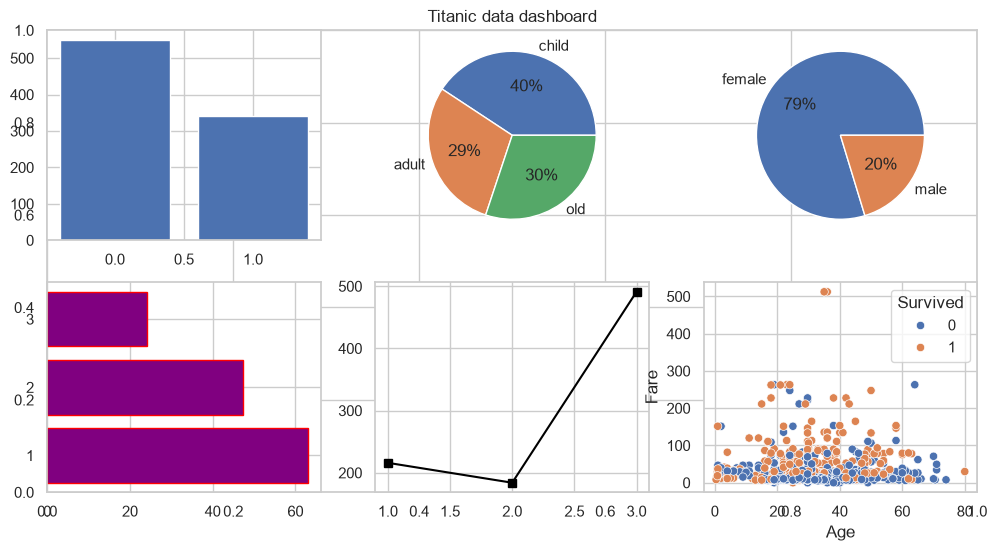

In [49]:
plt.figure(figsize=(12,6))
plt.title("Titanic data dashboard")
plt.subplot(2,3,1)
plt.bar(a.index,a.values)
plt.subplot(2,3,2)
plt.pie(b.values,labels=b.index,autopct="%1d%%")
plt.subplot(2,3,3)
plt.pie(c.values,labels=c.index,autopct="%1d%%")
plt.subplot(2,3,4)
plt.barh(d.index,d.values,color="purple",edgecolor="red")
plt.subplot(2,3,5)
plt.plot(e.index,e.values,marker="s",color="black")
plt.grid(True)
plt.subplot(2,3,6)
sns.scatterplot(x='Age',y='Fare',hue="Survived",data=df)

plt.show()

In [ ]:
++